In [14]:
import math 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import cycle
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.pyplot import cm
import glob
import os

import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")
#!pip install xlrd
#!pip install openpyxl

#!pip install mplcursors

#!pip install xlsxwriter
pi = (math. pi)


e = (math.e )



%matplotlib notebook
from pylab import rcParams
rcParams['figure.figsize'] =10,8

def define_figure(xlabel="X", ylabel="Y"):
    fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
    ax = plt.subplot(111)
    ax.grid(b=True, which='major', axis='both', color='#808080', linestyle='--')
    ax.set_xlabel(xlabel,size=20)
    ax.set_ylabel(ylabel,size=20)
    plt.tick_params(axis='both',labelsize=20)
    return ax

plt.rcParams["font.family"] = "Calibri"

In [15]:

# --- File setup ---
file_path = "SwFoT Veken -B_20260914.csv"

columns_to_keep = [
    "t_stamp",
    "cycle_id",
    "capacity",
    "voltage",
    "current",
    "energy",
    "displacement",
    "load",
    "project_id"
]

# --- Load CSV ---
df1 = pd.read_csv(file_path, header=0, usecols=columns_to_keep)


# --- Display results ---
print(df1.head())


           t_stamp  cycle_id  capacity  voltage  current    energy  \
0  7/17/2026 14:08       239   51.5020   2.8804  84.1087  133.1747   
1  7/17/2026 14:10       239   58.7508   3.0773 -78.7099  184.4327   
2  7/17/2026 14:10       239   53.9705   2.8990  83.5701  140.3077   
3  7/17/2026 14:12       239   61.8163   3.0689 -78.9423  193.8533   
4  7/17/2026 14:12       239   57.2065   2.9235  82.8524  149.7286   

   displacement      load project_id  
0          2140  667.0782   CS2C4100  
1           675  568.1785   CS2C4125  
2          2160  663.0777   CS2C4100  
3           675  568.5597   CS2C4125  
4          2175  657.7673   CS2C4100  


In [3]:
'''
# --- File setup ---
file_path = "Cell_Validation_cycle_id140.csv"

columns_to_keep = [
    "t_stamp",
    "cycle_id",
    "capacity",
    "voltage",
    "current",
    "energy",
    "displacement",
    "load",
    "project_id"
]

# --- Load CSV ---
df2 = pd.read_csv(file_path, header=0, usecols=columns_to_keep)


# --- Display results ---
#print(df2.head())
'''

'\n# --- File setup ---\nfile_path = "Cell_Validation_cycle_id140.csv"\n\ncolumns_to_keep = [\n    "t_stamp",\n    "cycle_id",\n    "capacity",\n    "voltage",\n    "current",\n    "energy",\n    "displacement",\n    "load",\n    "project_id"\n]\n\n# --- Load CSV ---\ndf2 = pd.read_csv(file_path, header=0, usecols=columns_to_keep)\n\n\n# --- Display results ---\n#print(df2.head())\n'

In [16]:
# --- Split into two dataframes by project_id ---
df_CS2C4125_1 = df1[df1["project_id"] == "CS2C4125"].reset_index(drop=True)
df_CS2C4100_1 = df1[df1["project_id"] == "CS2C4100"].reset_index(drop=True)

#df_CS2C4125_2 = df2[df2["project_id"] == "CS2C4125"].reset_index(drop=True)
#df_CS2C4100_2 = df2[df2["project_id"] == "CS2C4100"].reset_index(drop=True)

print("Rows in CS2C4125:", df_CS2C4125_1.shape[0])
print("Rows in CS2C4100:", df_CS2C4100_1.shape[0])

#print("Rows in CS2C4125:", df_CS2C4125_2.shape[0])
#print("Rows in CS2C4100:", df_CS2C4100_2.shape[0])

# --- Function to extract max load row per cycle_id ---
def get_max_load_per_cycle(df):
    return (
        df.loc[df.groupby("cycle_id")["load"].idxmax()]
        .reset_index(drop=True)
    )


# --- Apply to each dataset ---
df_max_CS2C4125_1 = get_max_load_per_cycle(df_CS2C4125_1)
df_max_CS2C4100_1 = get_max_load_per_cycle(df_CS2C4100_1)

#df_max_CS2C4125_2 = get_max_load_per_cycle(df_CS2C4125_2)
#df_max_CS2C4100_2 = get_max_load_per_cycle(df_CS2C4100_2)

# --- Display results ---
print("\nMax-load rows for CS2C4125_1:")
print(df_max_CS2C4125_1.tail())

#print("\nMax-load rows for CS2C4125_2:")
#print(df_max_CS2C4125_2.tail())

#print("\nMax-load rows for CS2C4100_1:")
#print(df_max_CS2C4100_1.tail())

#print("\nMax-load rows for CS2C4100_2:")
#print(df_max_CS2C4100_2.tail())

print("\nNumber of cycles found in CS2C4125:", df_max_CS2C4125_1.shape[0])
print("Number of cycles found in CS2C4100:", df_max_CS2C4100_1.shape[0])

#print("\nNumber of cycles found in CS2C4125:", df_max_CS2C4125_2.shape[0])
#print("Number of cycles found in CS2C4100:", df_max_CS2C4100_2.shape[0])


# --- Function to extract max displacement per cycle_id ---
def get_max_displacement_per_cycle(df):
    agg = df.groupby('cycle_id')['displacement'].max().reset_index()
    agg.rename(columns={'displacement': 'max_displacement'}, inplace=True)
    return agg

# --- Function to compute displacement range (max - min) per cycle_id ---
def get_displacement_range_per_cycle(df):
    agg = df.groupby('cycle_id')['displacement'].agg(
        max_displacement='max', min_displacement='min'
    ).reset_index()
    agg['displacement_range'] = agg['max_displacement'] - agg['min_displacement']
    return agg


# --- Apply new aggregation functions ---
df_max_disp_CS2C4125_1 = get_max_displacement_per_cycle(df_CS2C4125_1)
df_max_disp_CS2C4100_1 = get_max_displacement_per_cycle(df_CS2C4100_1)

df_disp_range_CS2C4125_1 = get_displacement_range_per_cycle(df_CS2C4125_1)
df_disp_range_CS2C4100_1 = get_displacement_range_per_cycle(df_CS2C4100_1)

print('\nMax-displacement rows for CS2C4125_1:')
print(df_max_disp_CS2C4125_1.tail())
print('\nDisplacement-range rows for CS2C4125_1:')
print(df_disp_range_CS2C4125_1.tail())


Rows in CS2C4125: 83058
Rows in CS2C4100: 83058

Max-load rows for CS2C4125_1:
             t_stamp  cycle_id  capacity  voltage   current    energy  \
483   9/14/2026 3:24       522  121.6987   2.7742  -87.3259  370.6843   
484   9/14/2026 8:18       523    0.0000   1.7312    0.0000    0.0000   
485   9/14/2026 8:30       524    5.9237   2.1616  112.0778   12.1812   
486  5/23/2026 18:17       655  154.6262   2.3078 -104.9698  455.9364   
487   5/27/2026 9:19       760   26.2270   2.7828    0.0000   62.4768   

     displacement      load project_id  
483           290  554.8075   CS2C4125  
484           350  556.2410   CS2C4125  
485           790  553.9103   CS2C4125  
486          3375  696.7756   CS2C4125  
487          -370  668.3406   CS2C4125  

Number of cycles found in CS2C4125: 488
Number of cycles found in CS2C4100: 489

Max-displacement rows for CS2C4125_1:
     cycle_id  max_displacement
483       522               835
484       523               835
485       524       

In [17]:
# --- Stitch max-load dataframes together ---
#df_max_CS2C4125_combined = pd.concat([df_max_CS2C4125_1, df_max_CS2C4125_2], ignore_index=True)
#df_max_CS2C4100_combined = pd.concat([df_max_CS2C4100_1, df_max_CS2C4100_2], ignore_index=True)

# --- Sort by cycle_id (optional, but recommended) ---
#df_max_CS2C4125_combined = df_max_CS2C4125_combined.sort_values("cycle_id").reset_index(drop=True)
#df_max_CS2C4100_combined = df_max_CS2C4100_combined.sort_values("cycle_id").reset_index(drop=True)

# --- Display results ---
#print("Combined CS2C4125 cycles:", df_max_CS2C4125_combined.shape[0])
#print("Combined CS2C4100 cycles:", df_max_CS2C4100_combined.shape[0])

#print("\nSample from combined CS2C4125:")
#print(df_max_CS2C4125_combined.tail())

#print("\nSample from combined CS2C4100:")
#print(df_max_CS2C4100_combined.head())


In [6]:
'''
import matplotlib.pyplot as plt
%matplotlib inline
# --- Plot Max Load vs Cycle Number ---
plt.figure(figsize=(10, 6))

plt.plot(
    df_CS2C4125_2["t_stamp"],
    df_CS2C4125_2["load"]*0.45359237,
    label="CS2C4125",
    marker='o'
)

#plt.plot(
    #df_CS2C4100["t_stamp"],
    #df_CS2C4100["load"]*0.45359237,
    #label="CS2C4100",
    #marker='s'
#)

plt.xlabel("t_stamp", fontsize=14)
plt.ylabel("Max Load (kgf)", fontsize=14)
plt.title("Max Load vs Cycle Number", fontsize=16)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
'''

'\nimport matplotlib.pyplot as plt\n%matplotlib inline\n# --- Plot Max Load vs Cycle Number ---\nplt.figure(figsize=(10, 6))\n\nplt.plot(\n    df_CS2C4125_2["t_stamp"],\n    df_CS2C4125_2["load"]*0.45359237,\n    label="CS2C4125",\n    marker=\'o\'\n)\n\n#plt.plot(\n    #df_CS2C4100["t_stamp"],\n    #df_CS2C4100["load"]*0.45359237,\n    #label="CS2C4100",\n    #marker=\'s\'\n#)\n\nplt.xlabel("t_stamp", fontsize=14)\nplt.ylabel("Max Load (kgf)", fontsize=14)\nplt.title("Max Load vs Cycle Number", fontsize=16)\nplt.legend()\nplt.grid(False)\nplt.tight_layout()\nplt.show()\n'

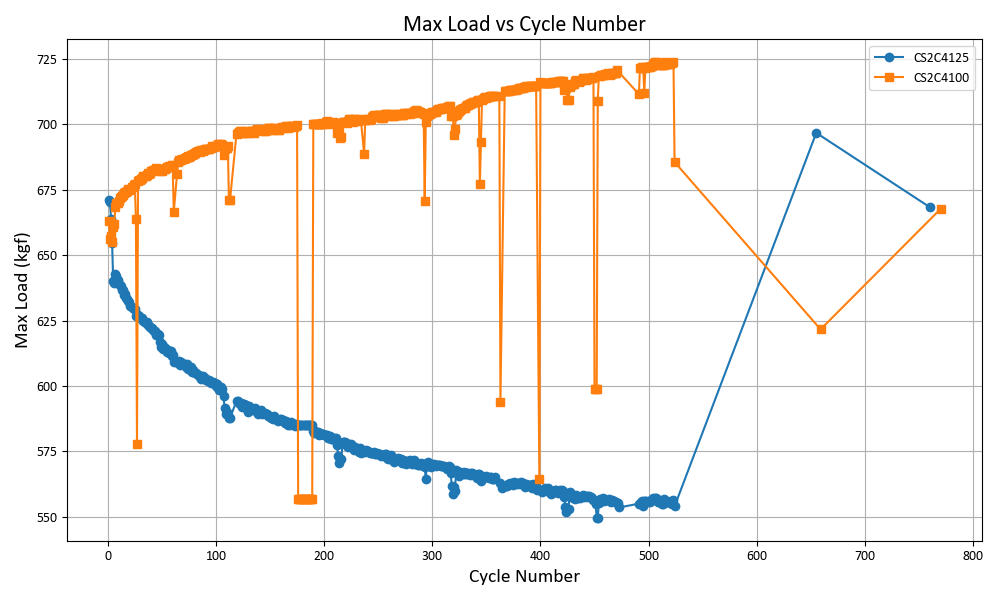

In [30]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor

%matplotlib widget  
# use notebook backend for interactive cursor

# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot your two datasets
line1, = ax.plot(
    df_max_CS2C4125_1["cycle_id"],
    df_max_CS2C4125_1["load"],
    label="CS2C4125",
    marker='o',
    linestyle='-'
)

line2, = ax.plot(
    df_max_CS2C4100_1["cycle_id"],
    df_max_CS2C4100_1["load"],
    label="CS2C4100",
    marker='s',
    linestyle='-'
)

# Add grid, labels, title, legend
ax.set_xlabel("Cycle Number", fontsize=14)
ax.set_ylabel("Max Load (kgf)", fontsize=14)
ax.set_title("Max Load vs Cycle Number", fontsize=16)
ax.legend()
ax.grid(True)

# --- Add interactive cursor ---
cursor = Cursor(ax, useblit=True, color='red', linewidth=1)

# --- Optional: Print coordinates on click ---
def on_click(event):
    if event.inaxes == ax:
        print(f"Cycle: {event.xdata:.0f}, Load (kgf): {event.ydata:.2f}")

fig.canvas.mpl_connect('button_press_event', on_click)

plt.tight_layout()
plt.show()


In [33]:
# --- Input the cycles with dips manually ---
# Example: dips at cycles 5, 12, 27
cycles_to_remove_CS2C4125 = [60,124,188,220,395,655,656,657,759,760,761,762,763,764]  # <-- enter your identified cycles here
cycles_to_remove_CS2C4100 = [25,26,27,52,60,61,62,63,65,66,67,111,112,113,117,124,*range(176,190),220,292,327,364,365,366,398,399,400,450,451,452,659,660,770] # <-- enter your identified cycles here

# --- Remove the specified cycles ---
df_clean_CS2C4125 = df_max_CS2C4125_1[~df_max_CS2C4125_1["cycle_id"].isin(cycles_to_remove_CS2C4125)].copy()
df_clean_CS2C4100 = df_max_CS2C4100_1[~df_max_CS2C4100_1["cycle_id"].isin(cycles_to_remove_CS2C4100)].copy()

# --- Optional: print summary ---
print("CS2C4125: removed cycles", cycles_to_remove_CS2C4125, ", remaining cycles:", df_clean_CS2C4125.shape[0])
print("CS2C4100: removed cycles", cycles_to_remove_CS2C4100, ", remaining cycles:", df_clean_CS2C4100.shape[0])

# --- Apply same cycle exclusions to max-displacement and range dataframes ---
df_clean_max_disp_CS2C4125 = df_max_disp_CS2C4125_1[
    ~df_max_disp_CS2C4125_1['cycle_id'].isin(cycles_to_remove_CS2C4125)
].copy()
df_clean_max_disp_CS2C4100 = df_max_disp_CS2C4100_1[
    ~df_max_disp_CS2C4100_1['cycle_id'].isin(cycles_to_remove_CS2C4100)
].copy()

df_clean_disp_range_CS2C4125 = df_disp_range_CS2C4125_1[
    ~df_disp_range_CS2C4125_1['cycle_id'].isin(cycles_to_remove_CS2C4125)
].copy()
df_clean_disp_range_CS2C4100 = df_disp_range_CS2C4100_1[
    ~df_disp_range_CS2C4100_1['cycle_id'].isin(cycles_to_remove_CS2C4100)
].copy()

print('Cleaned max-displacement CS2C4125:', df_clean_max_disp_CS2C4125.shape[0], 'cycles')
print('Cleaned max-displacement CS2C4100:', df_clean_max_disp_CS2C4100.shape[0], 'cycles')
print('Cleaned displacement-range CS2C4125:', df_clean_disp_range_CS2C4125.shape[0], 'cycles')
print('Cleaned displacement-range CS2C4100:', df_clean_disp_range_CS2C4100.shape[0], 'cycles')


CS2C4125: removed cycles [60, 124, 188, 220, 395, 655, 656, 657, 759, 760, 761, 762, 763, 764] , remaining cycles: 481
CS2C4100: removed cycles [25, 26, 27, 52, 60, 61, 62, 63, 65, 66, 67, 111, 112, 113, 117, 124, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 220, 292, 327, 364, 365, 366, 398, 399, 400, 450, 451, 452, 659, 660, 770] , remaining cycles: 452
Cleaned max-displacement CS2C4125: 481 cycles
Cleaned max-displacement CS2C4100: 452 cycles
Cleaned displacement-range CS2C4125: 481 cycles
Cleaned displacement-range CS2C4100: 452 cycles


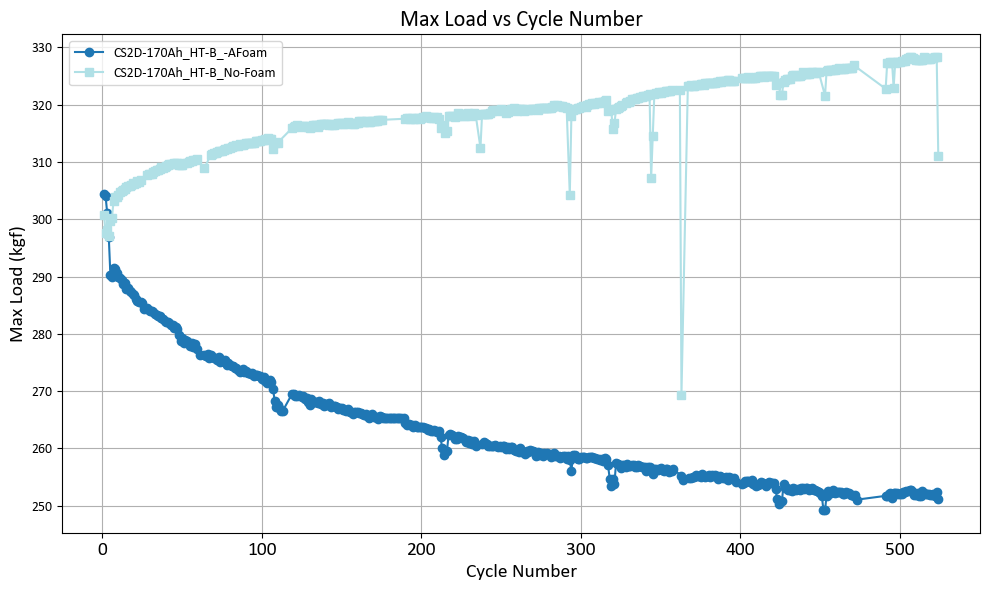

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline
# --- Plot Max Load vs Cycle Number ---
plt.figure(figsize=(10, 6))

plt.plot(
    df_clean_CS2C4125["cycle_id"],
    df_clean_CS2C4125["load"]*0.45359237,
    label="CS2D-170Ah_HT-B_-AFoam",
    marker='o'
)

plt.plot(
    df_clean_CS2C4100["cycle_id"],
    df_clean_CS2C4100["load"]*0.45359237,
    label="CS2D-170Ah_HT-B_No-Foam",
    marker='s',
    color='#b0e0e6'
)

plt.xlabel("Cycle Number", fontsize=14)
plt.ylabel("Max Load (kgf)", fontsize=14)
plt.title("Max Load vs Cycle Number", fontsize=16)
plt.xticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('20260918_MaxLoadvsCycleNumber_Veken-B_SwFoT_-Afoam_v5.png',dpi=300)

plt.show()


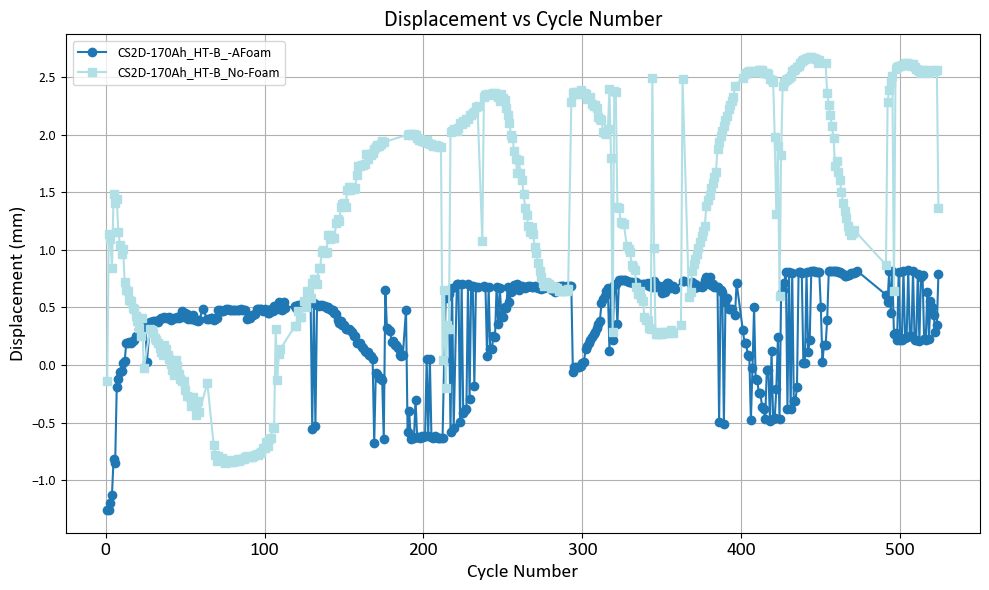

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline
# --- Plot Max Load vs Cycle Number ---
plt.figure(figsize=(10, 6))

plt.plot(
    df_clean_CS2C4125["cycle_id"],
    df_clean_CS2C4125["displacement"]/1000,
    label="CS2D-170Ah_HT-B_-AFoam",
    marker='o'
)

plt.plot(
    df_clean_CS2C4100["cycle_id"],
    df_clean_CS2C4100["displacement"]/1000,
    label="CS2D-170Ah_HT-B_No-Foam",
    marker='s',
    color='#b0e0e6'
)

plt.xlabel("Cycle Number", fontsize=14)
plt.ylabel("Displacement (mm)", fontsize=14)
plt.title("Displacement vs Cycle Number", fontsize=16)
plt.xticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('20260918_DisplacementvsCycleNumber_SwFoT_VekenHT-B_v2.png',dpi=300)

plt.show()

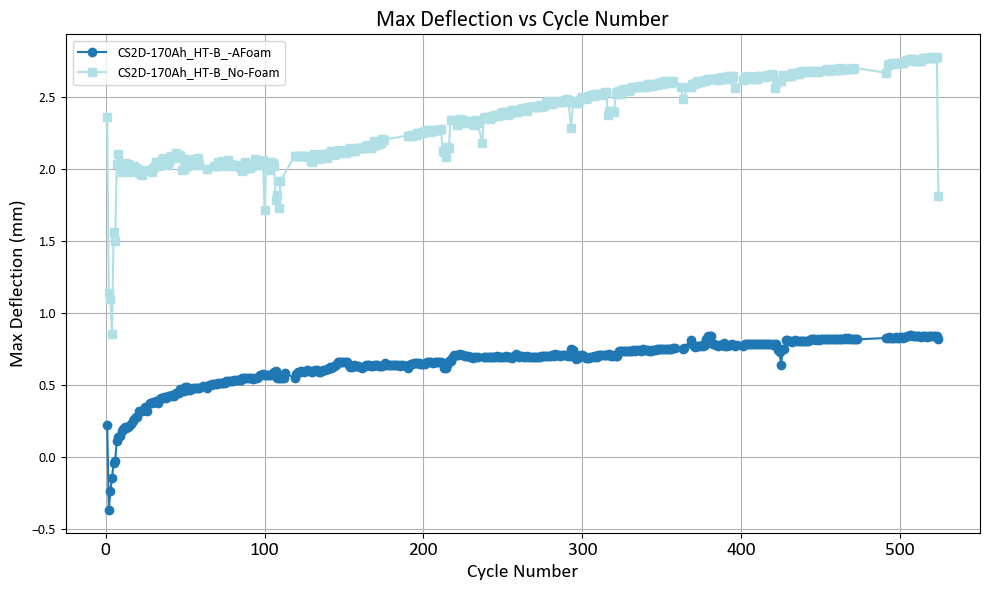

In [44]:
import matplotlib.pyplot as plt
%matplotlib inline
# --- Plot Max Deflection vs Cycle Number ---
plt.figure(figsize=(10, 6))

plt.plot(
    df_clean_max_disp_CS2C4125['cycle_id'],
    df_clean_max_disp_CS2C4125['max_displacement'] / 1000,
    label='CS2D-170Ah_HT-B_-AFoam',
    marker='o'
)

plt.plot(
    df_clean_max_disp_CS2C4100['cycle_id'],
    df_clean_max_disp_CS2C4100['max_displacement'] / 1000,
    label='CS2D-170Ah_HT-B_No-Foam',
    marker='s',
    color='#b0e0e6'
)

plt.xlabel('Cycle Number', fontsize=14)
plt.ylabel('Max Deflection (mm)', fontsize=14)
plt.title('Max Deflection vs Cycle Number', fontsize=16)
plt.xticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('20260918_MaxDeflectionvsCycleNumber_SwFoT_B1-foam_v1.png', dpi=300)

plt.show()

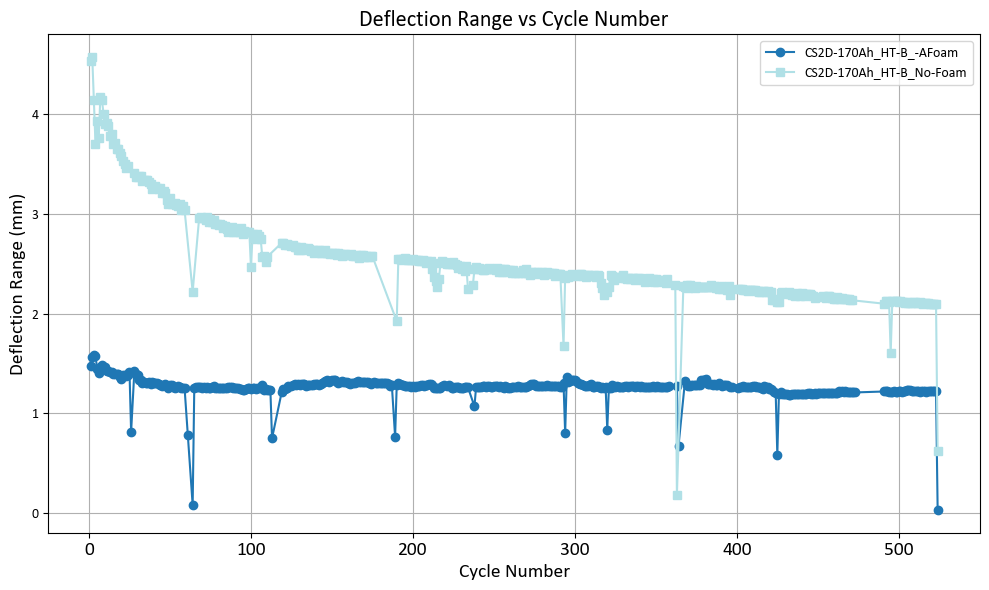

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline
# --- Plot Deflection Range vs Cycle Number ---
plt.figure(figsize=(10, 6))

plt.plot(
    df_clean_disp_range_CS2C4125['cycle_id'],
    df_clean_disp_range_CS2C4125['displacement_range'] / 1000,
    label='CS2D-170Ah_HT-B_-AFoam',
    marker='o'
)

plt.plot(
    df_clean_disp_range_CS2C4100['cycle_id'],
    df_clean_disp_range_CS2C4100['displacement_range'] / 1000,
    label='CS2D-170Ah_HT-B_No-Foam',
    marker='s',
    color='#b0e0e6'
)

plt.xlabel('Cycle Number', fontsize=14)
plt.ylabel('Deflection Range (mm)', fontsize=14)
plt.title('Deflection Range vs Cycle Number', fontsize=16)
plt.xticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('20260918_DeflectionRangevsCycleNumber_SwFoT_VekenHT-B_v1.png', dpi=300)

plt.show()

In [18]:
import pandas as pd

# ── Cell 1 (CS2C4125) ────────────────────────────────────────────────────────
# Base: every cycle where displacement data exists (probe was online throughout)
base_1 = df_max_disp_CS2C4125_1[['cycle_id']].copy().sort_values('cycle_id').reset_index(drop=True)

# Load: only cycles not in cycles_to_remove (sensor was offline for the rest)
load_1 = df_clean_CS2C4125[['cycle_id', 'load']].copy()
load_1['max_load_kgf'] = load_1['load'] * 0.45359237
load_1 = load_1[['cycle_id', 'max_load_kgf']]

# Max displacement per cycle (all cycles)
max_disp_1 = df_max_disp_CS2C4125_1[['cycle_id', 'max_displacement']].copy()
max_disp_1['max_displacement_mm'] = max_disp_1['max_displacement'] / 1000
max_disp_1 = max_disp_1[['cycle_id', 'max_displacement_mm']]

# Displacement range per cycle (all cycles)
range_1 = df_disp_range_CS2C4125_1[['cycle_id', 'displacement_range']].copy()
range_1['displacement_range_mm'] = range_1['displacement_range'] / 1000
range_1 = range_1[['cycle_id', 'displacement_range_mm']]

# Merge all onto base — load will be NaN for offline cycles
export_cell1 = base_1.merge(load_1,     on='cycle_id', how='left')
export_cell1 = export_cell1.merge(max_disp_1, on='cycle_id', how='left')
export_cell1 = export_cell1.merge(range_1,    on='cycle_id', how='left')

# ── Cell 2 (CS2C4100) ────────────────────────────────────────────────────────
base_2 = df_max_disp_CS2C4100_1[['cycle_id']].copy().sort_values('cycle_id').reset_index(drop=True)

load_2 = df_clean_CS2C4100[['cycle_id', 'load']].copy()
load_2['max_load_kgf'] = load_2['load'] * 0.45359237
load_2 = load_2[['cycle_id', 'max_load_kgf']]

max_disp_2 = df_max_disp_CS2C4100_1[['cycle_id', 'max_displacement']].copy()
max_disp_2['max_displacement_mm'] = max_disp_2['max_displacement'] / 1000
max_disp_2 = max_disp_2[['cycle_id', 'max_displacement_mm']]

range_2 = df_disp_range_CS2C4100_1[['cycle_id', 'displacement_range']].copy()
range_2['displacement_range_mm'] = range_2['displacement_range'] / 1000
range_2 = range_2[['cycle_id', 'displacement_range_mm']]

export_cell2 = base_2.merge(load_2,     on='cycle_id', how='left')
export_cell2 = export_cell2.merge(max_disp_2, on='cycle_id', how='left')
export_cell2 = export_cell2.merge(range_2,    on='cycle_id', how='left')

# ── Export to Excel ───────────────────────────────────────────────────────────
with pd.ExcelWriter('SwFoT_MaxLoadnDisplace_20260507_v5.xlsx', engine='xlsxwriter') as writer:
    export_cell1.to_excel(writer, sheet_name='CS2C-170Ah_HT-A_Cell1', index=False)
    export_cell2.to_excel(writer, sheet_name='CS2C-170Ah_HT-A_Cell2', index=False)

print('Export complete: SwFoT_MaxLoadnDisplace_20260507_v5.xlsx')
print(f'Cell1: {export_cell1.shape[0]} total cycles | {export_cell1["max_load_kgf"].notna().sum()} with load data')
print(f'Cell2: {export_cell2.shape[0]} total cycles | {export_cell2["max_load_kgf"].notna().sum()} with load data')


=== Slope Results (kgf per cycle) ===
CS2C4125 slope 115-220: 0.242026 kgf/cycle
CS2C4125 slope 222-393: 0.040454 kgf/cycle


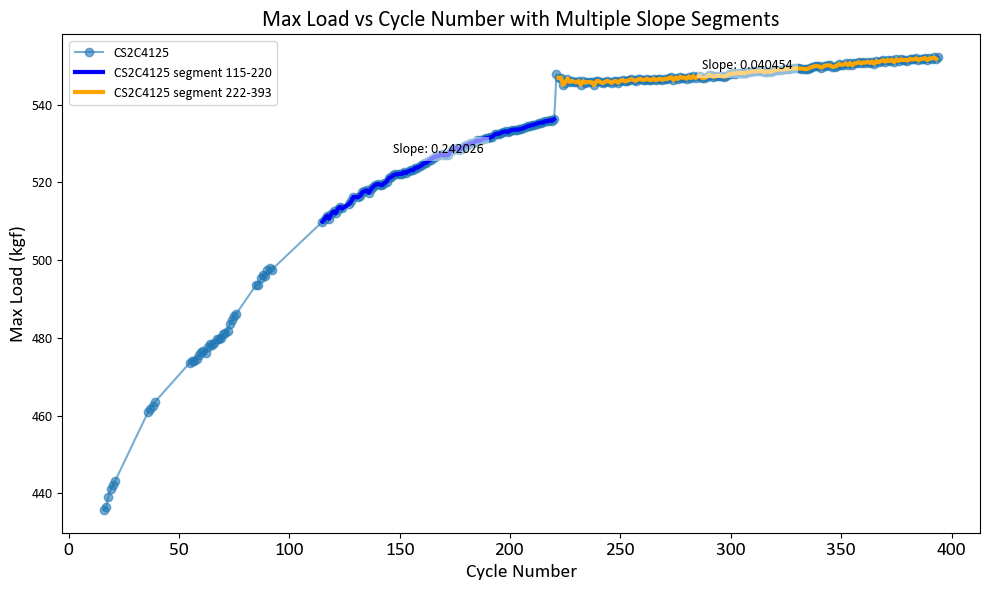

In [28]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# ============================================================
# === USER: MULTIPLE SLOPE SEGMENTS ==========================
# ============================================================

slope_segments = [
    (115, 220),
    (222, 393)        # <-- edit segments here
]

# ============================================================
# === CONVERT LOAD TO kgf ====================================
# ============================================================

df_clean_CS2C4125["load_kgf"] = df_clean_CS2C4125["load"] * 0.45359237

# ============================================================
# === SLOPE CALCULATION FUNCTION =============================
# ============================================================

def compute_slope(df, x_col="cycle_id", y_col="load_kgf",
                  start=None, end=None):

    mask = (df[x_col] >= start) & (df[x_col] <= end)
    df_section = df.loc[mask]

    if df_section.empty or df_section.shape[0] < 2:
        return None, None, None

    x = df_section[x_col].values
    y = df_section[y_col].values

    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept, df_section

# ============================================================
# === COMPUTE SLOPES FOR MULTIPLE SEGMENTS ===================
# ============================================================

slope_results_4125 = []

print("\n=== Slope Results (kgf per cycle) ===")

for (start_cycle, end_cycle) in slope_segments:
    s4125, i4125, sec4125 = compute_slope(df_clean_CS2C4125, start=start_cycle, end=end_cycle)
    slope_results_4125.append((start_cycle, end_cycle, s4125, sec4125))

    # Print results to console
    if s4125 is not None:
        print(f"CS2C4125 slope {start_cycle}-{end_cycle}: {s4125:.6f} kgf/cycle")
    else:
        print(f"CS2C4125 slope {start_cycle}-{end_cycle}: NOT ENOUGH DATA")

# ============================================================
# === PLOTTING ===============================================
# ============================================================

plt.figure(figsize=(10, 6))

# Full trace
plt.plot(df_clean_CS2C4125["cycle_id"], df_clean_CS2C4125["load_kgf"],
         label="CS2C4125", marker='o', alpha=0.6)

# Highlight slope segments and annotate slopes
colors = ["blue", "orange", "green", "red", "purple", "brown"]

for idx, (start, end, s4125, sec4125) in enumerate(slope_results_4125):
    color = colors[idx % len(colors)]
    if sec4125 is not None:
        # Highlight segment
        plt.plot(
            sec4125["cycle_id"],
            sec4125["load_kgf"],
            linewidth=3,
            color=color,
            label=f"CS2C4125 segment {start}-{end}"
        )
        # Annotate slope at midpoint
        mid_x = (start + end) / 2
        mid_y = np.interp(mid_x, sec4125["cycle_id"], sec4125["load_kgf"])
        plt.text(mid_x, mid_y,
                 f"Slope: {s4125:.6f}",
                 fontsize=10,
                 color='k',
                 ha='center',
                 va='bottom',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.xlabel("Cycle Number", fontsize=14)
plt.ylabel("Max Load (kgf)", fontsize=14)
plt.title("Max Load vs Cycle Number with Multiple Slope Segments", fontsize=16)
plt.xticks(fontsize=14)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig('SwFoT_CS2C4125_wifSlopes_v1')
plt.show()


=== Max Load ===
  check CS2C-170Ah_HT-A_Cell1: Logarithmic  R2=0.9920
  check CS2C-170Ah_HT-A_Cell2: Power law  R2=0.9846

=== Max Deflection ===
  Despiked CS2C-170Ah_HT-A_Cell1: removed 2 points
  check CS2C-170Ah_HT-A_Cell1: Power law  R2=0.9300
  Despiked CS2C-170Ah_HT-A_Cell2: removed 4 points
  check CS2C-170Ah_HT-A_Cell2: Logarithmic  R2=0.9939

=== Deflection Range ===
  Despiked CS2C-170Ah_HT-A_Cell1: removed 2 points
  check CS2C-170Ah_HT-A_Cell1: Power decay + asymptote  R2=0.8251
  Despiked CS2C-170Ah_HT-A_Cell2: removed 12 points
  check CS2C-170Ah_HT-A_Cell2: Power decay + asymptote  R2=0.9602


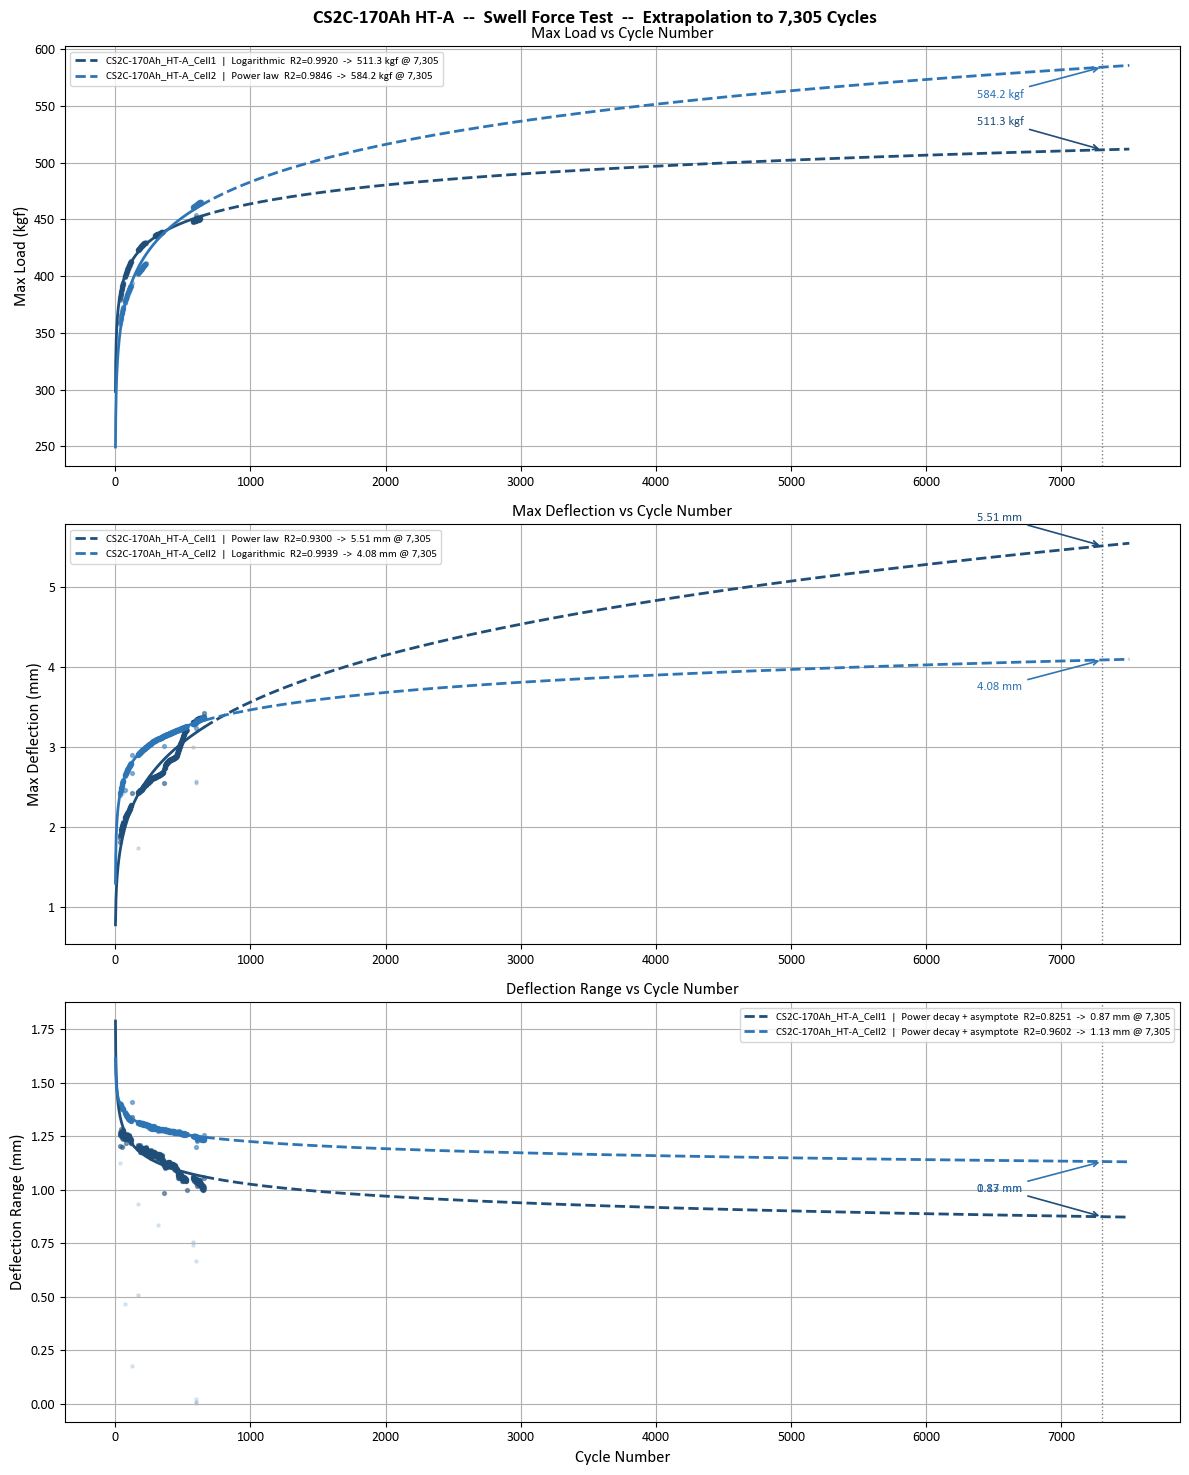


  EXTRAPOLATION SUMMARY AT 7,305 CYCLES
  Max Load     Cell1: 511.3 kgf  [Logarithmic]
  Max Load     Cell2: 584.2 kgf  [Power law]
  Max Deflect  Cell1: 5.51 mm  [Power law]
  Max Deflect  Cell2: 4.08 mm  [Logarithmic]
  Defl Range   Cell1: 0.87 mm  [Power decay + asymptote]
  Defl Range   Cell2: 1.13 mm  [Power decay + asymptote]


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib inline

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS  (tune here)
# ─────────────────────────────────────────────────────────────────────────────
TARGET_CYCLE = 7305
ROLL_WINDOW  = 15      # rolling-median window for outlier filter (cycles)
SPIKE_THRESH = 0.15    # mm — points more than this BELOW rolling median are excluded

# ─────────────────────────────────────────────────────────────────────────────
# MODEL DEFINITIONS
# ─────────────────────────────────────────────────────────────────────────────
def power_law(x, a, b):
    # Monotonically increasing: y = a * x^b
    return a * np.power(x, b)

def log_model(x, a, b):
    # Logarithmic: y = a * ln(x) + b
    return a * np.log(x) + b

def linear_model(x, m, c):
    return m * x + c

def power_decay(x, a, b, c):
    # Decaying power law with asymptote: a * x^-b + c
    return a * np.power(x, -b) + c

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot

# ─────────────────────────────────────────────────────────────────────────────
# ROLLING MEDIAN SPIKE FILTER  (removes downward artifacts)
# ─────────────────────────────────────────────────────────────────────────────
def despike(x_arr, y_arr, window=ROLL_WINDOW, thresh=SPIKE_THRESH):
    # Exclude points that sit more than `thresh` mm below the local rolling median
    s   = pd.Series(y_arr)
    med = s.rolling(window, center=True, min_periods=3).median().fillna(s.median())
    mask = (med.values - y_arr) <= thresh
    return x_arr[mask], y_arr[mask], int((~mask).sum())

# ─────────────────────────────────────────────────────────────────────────────
# FIT SELECTOR — increasing metrics  (power law vs. logarithmic)
# ─────────────────────────────────────────────────────────────────────────────
def fit_increasing(x, y, tag):
    b0 = float(np.clip(np.log(y[-1] / y[0]) / np.log(x[-1] / x[0]), 0.01, 0.99))
    a0 = float(y[0] / x[0] ** b0)
    da = max(1.0, float(np.ptp(y)) / np.log(x[-1] / x[0]))
    candidates = {
        'Power law':   (power_law,  [a0, b0]),
        'Logarithmic': (log_model,  [da, float(y[0])]),
    }
    results = {}
    for name, (func, p0) in candidates.items():
        try:
            popt, _ = curve_fit(func, x, y, p0=p0, maxfev=10000)
            yhat = func(x, *popt)
            results[name] = {'func': func, 'params': popt, 'r2': r2_score(y, yhat)}
        except Exception as e:
            print(f"    {name} failed ({tag}): {e}")
    if not results:
        raise RuntimeError(f"All increasing fits failed for {tag}")
    best_name = max(results, key=lambda k: results[k]['r2'])
    print(f"  check {tag}: {best_name}  R2={results[best_name]['r2']:.4f}")
    return best_name, results[best_name]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE SETUP
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle(
    f'CS2C-170Ah HT-A  --  Swell Force Test  --  Extrapolation to {TARGET_CYCLE:,} Cycles',
    fontsize=14, fontweight='bold'
)

x_full = np.linspace(1, TARGET_CYCLE + 200, 4000)

CELLS = [
    dict(df_load=df_clean_CS2C4125,
         df_mdisp=df_max_disp_CS2C4125_1,
         df_range=df_disp_range_CS2C4125_1,
         color='#1f4e79', label='CS2C-170Ah_HT-A_Cell1'),
    dict(df_load=df_clean_CS2C4100,
         df_mdisp=df_max_disp_CS2C4100_1,
         df_range=df_disp_range_CS2C4100_1,
         color='#2e75b6', label='CS2C-170Ah_HT-A_Cell2'),
]
annot_dy = [18, -22]
summary  = []

# PANEL 1 - Max Load
print("=== Max Load ===")
ax = axes[0]
for i, cs in enumerate(CELLS):
    x = cs['df_load']['cycle_id'].values.astype(float)
    y = (cs['df_load']['load'] * 0.45359237).values

    model_name, best = fit_increasing(x, y, cs['label'])
    f, p = best['func'], best['params']
    val   = float(f(TARGET_CYCLE, *p))
    y_fit = f(x_full, *p)

    ax.scatter(x, y, s=8, color=cs['color'], alpha=0.35, zorder=2)
    ax.plot(x_full[x_full <= x.max()], y_fit[x_full <= x.max()],
            color=cs['color'], lw=2, zorder=3)
    ax.plot(x_full[x_full > x.max()], y_fit[x_full > x.max()],
            color=cs['color'], lw=2, ls='--', zorder=3,
            label=f"{cs['label']}  |  {model_name}  R2={best['r2']:.4f}  ->  {val:.1f} kgf @ {TARGET_CYCLE:,}")
    ax.annotate(f"{val:.1f} kgf",
                xy=(TARGET_CYCLE, val), xytext=(-90, annot_dy[i]),
                textcoords='offset points', fontsize=9, color=cs['color'],
                arrowprops=dict(arrowstyle='->', color=cs['color'], lw=1.2))
    summary.append(f"  Max Load     {cs['label'][-5:]}: {val:.1f} kgf  [{model_name}]")

ax.axvline(TARGET_CYCLE, color='gray', lw=1, ls=':')
ax.set_ylabel('Max Load (kgf)', fontsize=12)
ax.set_title('Max Load vs Cycle Number', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)

# PANEL 2 - Max Deflection
print("\n=== Max Deflection ===")
ax = axes[1]
for i, cs in enumerate(CELLS):
    x_raw = cs['df_mdisp']['cycle_id'].values.astype(float)
    y_raw = (cs['df_mdisp']['max_displacement'] / 1000).values
    x_cl, y_cl, n_rm = despike(x_raw, y_raw)
    print(f"  Despiked {cs['label']}: removed {n_rm} points")

    model_name, best = fit_increasing(x_cl, y_cl, cs['label'])
    f, p = best['func'], best['params']
    val   = float(f(TARGET_CYCLE, *p))
    y_fit = f(x_full, *p)

    ax.scatter(x_raw, y_raw, s=5, color=cs['color'], alpha=0.15, zorder=1, label='_')
    ax.scatter(x_cl,  y_cl,  s=8, color=cs['color'], alpha=0.45, zorder=2, label='_')
    ax.plot(x_full[x_full <= x_raw.max()], y_fit[x_full <= x_raw.max()],
            color=cs['color'], lw=2, zorder=3)
    ax.plot(x_full[x_full > x_raw.max()], y_fit[x_full > x_raw.max()],
            color=cs['color'], lw=2, ls='--', zorder=3,
            label=f"{cs['label']}  |  {model_name}  R2={best['r2']:.4f}  ->  {val:.2f} mm @ {TARGET_CYCLE:,}")
    ax.annotate(f"{val:.2f} mm",
                xy=(TARGET_CYCLE, val), xytext=(-90, annot_dy[i]),
                textcoords='offset points', fontsize=9, color=cs['color'],
                arrowprops=dict(arrowstyle='->', color=cs['color'], lw=1.2))
    summary.append(f"  Max Deflect  {cs['label'][-5:]}: {val:.2f} mm  [{model_name}]")

ax.axvline(TARGET_CYCLE, color='gray', lw=1, ls=':')
ax.set_ylabel('Max Deflection (mm)', fontsize=12)
ax.set_title('Max Deflection vs Cycle Number', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)

# PANEL 3 - Deflection Range
print("\n=== Deflection Range ===")
ax = axes[2]
for i, cs in enumerate(CELLS):
    x_raw = cs['df_range']['cycle_id'].values.astype(float)
    y_raw = (cs['df_range']['displacement_range'] / 1000).values
    x_cl, y_cl, n_rm = despike(x_raw, y_raw)
    print(f"  Despiked {cs['label']}: removed {n_rm} points")

    # Linear fit
    popt_lin, _ = curve_fit(linear_model, x_cl, y_cl)
    r2_lin  = r2_score(y_cl, linear_model(x_cl, *popt_lin))
    val_lin = linear_model(TARGET_CYCLE, *popt_lin)

    # Power decay with asymptote
    use_decay = False
    try:
        c0 = float(max(0.01, np.min(y_cl) - 0.05))
        a0 = float(y_cl[0]) - c0
        popt_dec, _ = curve_fit(
            power_decay, x_cl, y_cl,
            p0=[a0, 0.15, c0],
            bounds=([0, 1e-4, 0], [np.inf, 2.0, np.inf]),
            maxfev=10000
        )
        r2_dec  = r2_score(y_cl, power_decay(x_cl, *popt_dec))
        val_dec = float(power_decay(TARGET_CYCLE, *popt_dec))
        use_decay = (r2_dec > r2_lin) or (val_lin < 0)
        if use_decay:
            print(f"  check {cs['label']}: Power decay + asymptote  R2={r2_dec:.4f}")
        else:
            print(f"  check {cs['label']}: Linear  R2={r2_lin:.4f}")
    except Exception as e:
        print(f"  Power decay failed ({cs['label']}): {e}")
        print(f"  check {cs['label']}: Linear  R2={r2_lin:.4f}")

    if use_decay:
        f_r, p_r, r2_r = power_decay,  popt_dec, r2_dec
        val_r = max(val_dec, 0.0)
        lbl_r = 'Power decay + asymptote'
    else:
        f_r, p_r, r2_r = linear_model, popt_lin, r2_lin
        val_r = max(val_lin, 0.0)
        lbl_r = 'Linear'

    y_fit = np.maximum(f_r(x_full, *p_r), 0.0)

    ax.scatter(x_raw, y_raw, s=5, color=cs['color'], alpha=0.15, zorder=1, label='_')
    ax.scatter(x_cl,  y_cl,  s=8, color=cs['color'], alpha=0.45, zorder=2, label='_')
    ax.plot(x_full[x_full <= x_raw.max()], y_fit[x_full <= x_raw.max()],
            color=cs['color'], lw=2, zorder=3)
    ax.plot(x_full[x_full > x_raw.max()], y_fit[x_full > x_raw.max()],
            color=cs['color'], lw=2, ls='--', zorder=3,
            label=f"{cs['label']}  |  {lbl_r}  R2={r2_r:.4f}  ->  {val_r:.2f} mm @ {TARGET_CYCLE:,}")
    ax.annotate(f"{val_r:.2f} mm",
                xy=(TARGET_CYCLE, val_r), xytext=(-90, annot_dy[i]),
                textcoords='offset points', fontsize=9, color=cs['color'],
                arrowprops=dict(arrowstyle='->', color=cs['color'], lw=1.2))
    summary.append(f"  Defl Range   {cs['label'][-5:]}: {val_r:.2f} mm  [{lbl_r}]")

ax.axvline(TARGET_CYCLE, color='gray', lw=1, ls=':')
ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Deflection Range (mm)', fontsize=12)
ax.set_title('Deflection Range vs Cycle Number', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True)

plt.tight_layout()
#plt.savefig('SwFoT_Extrapolation_7305cycles_v1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*65}")
print(f"  EXTRAPOLATION SUMMARY AT {TARGET_CYCLE:,} CYCLES")
print(f"{'='*65}")
for line in summary:
    print(line)
print(f"{'='*65}")
